데이터 피쳐 수: 30
클래스 분포: [212 357]

[Phase 1: 과적합 진단]
Train Accuracy: 1.0000
Test Accuracy: 0.9474
트리 깊이: 7


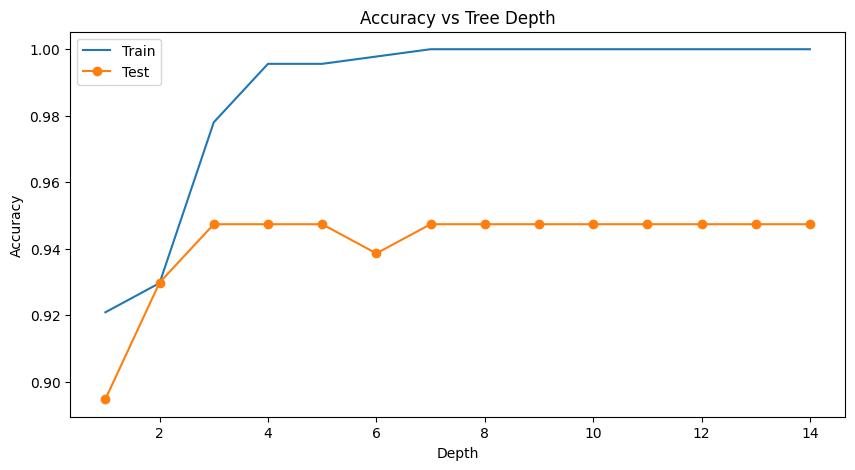

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. 실제 라이브러리 데이터셋 로드
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns = data.feature_names)
y = data.target 

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size =0.2, random_state=42)

print(f"데이터 피쳐 수: {len(data.feature_names)}")
print(f"클래스 분포: {np.bincount(y)}")

base_model = DecisionTreeClassifier(random_state = 42)
base_model.fit(X_train,y_train)

print("\n[Phase 1: 과적합 진단]")
print(f"Train Accuracy: {base_model.score(X_train, y_train):.4f}")
print(f"Test Accuracy: {base_model.score(X_test, y_test):.4f}")
print(f"트리 깊이: {base_model.get_depth()}")

#학습 곡선 시각화
depths = range(1,15)
train_scores, test_scores =[],[]
for d in depths:
    clf = DecisionTreeClassifier(max_depth = d, random_state= 42).fit(X_train, y_train)
    train_scores.append(clf.score(X_train,y_train))
    test_scores.append(clf.score(X_test,y_test))

plt.figure(figsize = (10,5))
plt.plot(depths, train_scores, label = 'Train')
plt.plot(depths, test_scores, label = 'Test', marker = 'o')
plt.title('Accuracy vs Tree Depth')
plt.xlabel('Depth')
plt.ylabel('Accuracy')
plt.legend()
plt.show()